# <-- Unsupervised -->

>Basically, the idea is to use data samples which have status id 0 in the train(train_test feature) segment of the dataset. 

>We choose this approach as we realised during the data analysis and preprocessing that. all the other status ids are flagged faults already known by the operators. 

>And the developing anomalies are usually in he normal data as we are doing predictive maintenance. 

>So this a key factor to look for anomaly samples in normal data points or basically deviationin in the normal points. With this approach it can be easy to generalise across different turbines.


In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
from utils import *
from model import *
import warnings
warnings.filterwarnings("ignore")
from sklearn.decomposition import PCA
import hdbscan
import plotly.express as px
from sklearn.metrics import silhouette_score
import umap.umap_ as umap


In [2]:
df_anomaly= pd.read_csv(r"44.csv", delimiter=";")

# Data Processing

The Preprocesspipeline function is used to drop min and max columns and also it takes list of merge sensors and drop sensors which was finalised in utils.py file. The function is automated for simplicity purpose and ore interpretability.
the result is 240 feature with avg and std features

In [3]:
df_hourly_train = df_anomaly.copy()
df_hourly_train = preprocess_pipeline(df_hourly_train)
df_hourly_train = df_hourly_train[df_hourly_train['train_test'] == 'train']
df_hourly_train = df_hourly_train[df_hourly_train['status_type_id'] == 0]

In [4]:
df_hourly_test =df_anomaly.copy()
df_hourly_test = preprocess_pipeline(df_hourly_test)
df_hourly_test = df_hourly_test[df_hourly_test['train_test'] == 'prediction']

# UMAP + HDBSCAN

# the down sampled data @60min interval per sample

In [5]:
def downsample_to_hourly_with_index(df, time_col="time_stamp", interval_minutes=10):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)
    df["original_index"] = df.index  # Save original index
    df = df.set_index(time_col)

    df = df.asfreq(f"{interval_minutes}min", method='pad')
    grouped = df.groupby(pd.Grouper(freq="1H"))

    df_hourly = grouped.mean(numeric_only=True)
    df_hourly["source_indices"] = grouped["original_index"].apply(lambda x: list(x))

    valid_counts = grouped.count()
    valid_mask = (valid_counts >= 6).all(axis=1)
    df_hourly = df_hourly[valid_mask]

    df_hourly = df_hourly.reset_index()
    return df_hourly

# Optuna was used to get the hyperparameters

In [6]:
# import optuna
# from sklearn.metrics import silhouette_score
# import umap.umap_ as umap
# import hdbscan
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# def objective(trial):
#     # UMAP hyperparameters
#     n_neighbors = trial.suggest_int("n_neighbors", 5, 50)
#     min_dist = trial.suggest_float("min_dist", 0.0, 0.5)
#     metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])

#     # HDBSCAN hyperparameters
#     min_cluster_size = trial.suggest_int("min_cluster_size", 5, 50)
#     min_samples = trial.suggest_int("min_samples", 1, 30)

#     # Scale + PCA
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(df_hourly_train)
#     pca = PCA(n_components=0.95)
#     X_pca = pca.fit_transform(X_scaled)

#     # UMAP
#     reducer = umap.UMAP(
#         n_components=10,
#         n_neighbors=n_neighbors,
#         min_dist=min_dist,
#         metric=metric,
#         random_state=42
#     )
#     X_umap = reducer.fit_transform(X_pca)

#     # HDBSCAN
#     clusterer = hdbscan.HDBSCAN(
#         min_cluster_size=min_cluster_size,
#         min_samples=min_samples
#     )
#     labels = clusterer.fit_predict(X_umap)

#     # Silhouette score on non-noise points
#     mask = labels != -1
#     if mask.sum() > 1 and len(set(labels[mask])) > 1:
#         return silhouette_score(X_umap[mask], labels[mask])
#     else:
#         return -1.0

# # Run optimization
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=50)

# print("✅ Best Silhouette Score:", study.best_value)
# print("🏆 Best Parameters:", study.best_params)


# Clustering with UMAP

For Train data with status id ==0

In [7]:
df_hourly_train = downsample_to_hourly_with_index(df_hourly_train)

In [8]:
df_hourly_train = df_hourly_train.drop(columns=['time_stamp','asset_id','id','status_type_id', 'original_index','source_indices']  )

In [9]:
# === STEP 1: PCA (Reduce Noise) ===
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(df_hourly_train)

# === STEP 2: UMAP Embeddings ===
# Clustering space (10D)
umap_cluster = umap.UMAP(n_components=10, n_neighbors=14, min_dist=0.0387, random_state=42)
X_umap_cluster = umap_cluster.fit_transform(X_pca)

# Visualization space (3D)
umap_vis = umap.UMAP(n_components=3, n_neighbors=14, min_dist=0.0387, random_state=42)
X_umap_vis = umap_vis.fit_transform(X_pca)

# === STEP 3: HDBSCAN Clustering ===
clusterer = hdbscan.HDBSCAN(min_cluster_size=14, min_samples=18, prediction_data=True)
labels = clusterer.fit_predict(X_umap_cluster)
strengths = clusterer.probabilities_

# === STEP 4: Evaluate Cluster Quality ===
mask = labels != -1
if mask.sum() > 1 and len(set(labels[mask])) > 1:
    score = silhouette_score(X_umap_cluster[mask], labels[mask])
    print(f"✅ Silhouette Score (no noise): {score:.4f}")
else:
    print("❌ Not enough clustered points to compute Silhouette Score.")

# === STEP 5: Create DataFrame ===
df_vis = pd.DataFrame(X_umap_vis, columns=["UMAP1", "UMAP2", "UMAP3"])
df_vis["Cluster"] = labels
df_vis["Strength"] = strengths

# === STEP 6: Distance to Cluster Centroids ===
centroids = df_vis[df_vis["Cluster"] != -1].groupby("Cluster")[["UMAP1", "UMAP2", "UMAP3"]].mean()

def compute_distance(row):
    if row["Cluster"] == -1:
        return np.inf
    center = centroids.loc[row["Cluster"]].values
    point = row[["UMAP1", "UMAP2", "UMAP3"]].values
    return np.linalg.norm(point - center)

df_vis["DistToCenter"] = df_vis.apply(compute_distance, axis=1)

# === STEP 7: Cluster-wise Thresholds ===
dist_thresh = df_vis[df_vis["Cluster"] != -1].groupby("Cluster")["DistToCenter"].quantile(0.98)
cluster_sizes = df_vis[df_vis["Cluster"] != -1]["Cluster"].value_counts()

df_vis["ClusterDistThresh"] = df_vis["Cluster"].map(dist_thresh)
df_vis["ClusterSize"] = df_vis["Cluster"].map(cluster_sizes)

# === STEP 8: Final Anomaly Logic ===
df_vis["Anomaly"] = (
    (df_vis["Cluster"] == -1) |                                 # noise (marking noise)
    (df_vis["Strength"] < 0.3) |                                # weak membership (basically filtering small clusters)
    (df_vis["DistToCenter"] > df_vis["ClusterDistThresh"]) |   # if it is far from center
    (df_vis["ClusterSize"] < 10)                                # if the clusters are tiny clusters

).astype(int)
# Using rulebased clustering as i am filtering small cluster and marking noise at same time, this helps us with anomalies far from the cluster center will be marked as anomalies


#  Score for severity of the samples just to check the confidence of the sample in a cluster and scores it with respect to center of the cluster
df_vis["AnomalyScore"] = (1 - df_vis["Strength"]) + df_vis["DistToCenter"].fillna(0)

# === STEP 9: Visualize Results ===
fig = px.scatter_3d(
    df_vis, x="UMAP1", y="UMAP2", z="UMAP3",
    color="Anomaly",
    title="Refined Clustering-Based Anomaly Detection",
    color_discrete_map={0: "blue", 1: "red"}
)
fig.show()
 

✅ Silhouette Score (no noise): 0.6077


# For Predicition frame of data

In [10]:
# === STEP 0: Downsampling Function that Preserves Indices ===
df_hourly_test = downsample_to_hourly_with_index(df_hourly_test, time_col='time_stamp')
df_hourly_test = df_hourly_test.drop(columns=["time_stamp", "asset_id", "id", "status_type_id"], errors="ignore")


In [ ]:
def full_clustering_pipeline(df_hourly_test, fault_start=52704, fault_end=62138):
    """
    Perform anomaly detection using PCA, UMAP, and HDBSCAN clustering on time-series SCADA data.

    Parameters:
    -----------
    df_hourly_test : pd.DataFrame
        Input dataframe with hourly time series data, including a 'source_indices' column.
    fault_start : int, optional
        Start index of the fault window for labeling ground truth anomalies (default is 52704).
    fault_end : int, optional
        End index of the fault window for labeling ground truth anomalies (default is 62138).

    Returns:
    --------
    df_vis : pd.DataFrame
        Dataframe containing UMAP embeddings, cluster labels, anomaly flags, predictions, and visualization metadata.
    """

    # Import required libraries
    import pandas as pd
    import numpy as np
    import hdbscan
    import umap.umap_ as umap
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score
    import plotly.express as px

    # === STEP 1: PCA — Dimensionality reduction to reduce noise ===
    pca = PCA(n_components=3, random_state=42)
    X_pca = pca.fit_transform(df_hourly_test.drop(columns=["source_indices"]))

    # === STEP 2: UMAP — Project data into lower-dimensional embeddings for clustering and visualization ===
    umap_cluster = umap.UMAP(n_components=10, n_neighbors=14, min_dist=0.0387, random_state=42)
    X_umap_cluster = umap_cluster.fit_transform(X_pca)

    umap_vis = umap.UMAP(n_components=3, n_neighbors=14, min_dist=0.0387, random_state=42)
    X_umap_vis = umap_vis.fit_transform(X_pca)

    # === STEP 3: HDBSCAN — Density-based clustering to find meaningful groups ===
    clusterer = hdbscan.HDBSCAN(min_cluster_size=14, min_samples=18, prediction_data=True)
    labels = clusterer.fit_predict(X_umap_cluster)
    strengths = clusterer.probabilities_  # Membership strength of each point

    # === STEP 4: Evaluate clustering quality with silhouette score (excluding noise) ===
    mask = labels != -1  # Ignore noise points
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        score = silhouette_score(X_umap_cluster[mask], labels[mask])
        print(f"✅ Silhouette Score (no noise): {score:.4f}")
    else:
        print("❌ Not enough clustered points to compute Silhouette Score.")

    # === STEP 5: Create output dataframe for visualization ===
    df_vis = pd.DataFrame(X_umap_vis, columns=["UMAP1", "UMAP2", "UMAP3"])
    df_vis["Cluster"] = labels
    df_vis["Strength"] = strengths
    df_vis["source_indices"] = df_hourly_test["source_indices"]

    # === STEP 6: Compute distance of each point to its cluster centroid (for anomaly logic) ===
    centroids = df_vis[df_vis["Cluster"] != -1].groupby("Cluster")[["UMAP1", "UMAP2", "UMAP3"]].mean()

    def compute_distance(row):
        if row["Cluster"] == -1:
            return np.inf  # Noise points
        center = centroids.loc[row["Cluster"]].values
        point = row[["UMAP1", "UMAP2", "UMAP3"]].values
        return np.linalg.norm(point - center)

    df_vis["DistToCenter"] = df_vis.apply(compute_distance, axis=1)

    # === STEP 7: Calculate thresholds for outlier detection based on distance distribution per cluster ===
    dist_thresh = df_vis[df_vis["Cluster"] != -1].groupby("Cluster")["DistToCenter"].quantile(0.98)
    cluster_sizes = df_vis[df_vis["Cluster"] != -1]["Cluster"].value_counts()

    df_vis["ClusterDistThresh"] = df_vis["Cluster"].map(dist_thresh)
    df_vis["ClusterSize"] = df_vis["Cluster"].map(cluster_sizes)

    # === STEP 8: Identify anomalies using rule-based logic ===
    df_vis["Anomaly"] = (
        (df_vis["Cluster"] == -1) |  # Noise
        (df_vis["Strength"] < 0.3) |  # Low cluster membership confidence
        (df_vis["DistToCenter"] > df_vis["ClusterDistThresh"]) |  # Too far from cluster center
        (df_vis["ClusterSize"] < 10)  # Very small clusters
    ).astype(int)

    # Composite anomaly score for ranking or sorting
    df_vis["AnomalyScore"] = (1 - df_vis["Strength"]) + df_vis["DistToCenter"].fillna(0)

    # === STEP 9: CARE-Compatible Labels (binarized predictions for evaluation) ===
    valid_clusters = df_vis["Cluster"].value_counts().drop(-1, errors='ignore')
    if not valid_clusters.empty:
        normal_cluster = valid_clusters.idxmin()  # Least common cluster assumed to be normal
        df_vis["predictions"] = (~(df_vis["Cluster"] == normal_cluster)).astype(int)
        df_vis.loc[df_vis["Cluster"] == -1, "predictions"] = 1
    else:
        df_vis["predictions"] = 1  # All are anomalies if no valid clusters

    # === STEP 10: Label ground truth anomalies based on fault window ===
    def in_fault_window(indices):
        return any(fault_start <= i <= fault_end for i in indices)

    df_vis["ground_truth"] = df_vis["source_indices"].apply(in_fault_window).astype(int)

    # === STEP 11: Visualization — 3D UMAP plot with cluster and anomaly information ===
    df_vis["OriginalIndices"] = df_vis["source_indices"].apply(lambda x: str(x[:3]) + "..." if len(x) > 3 else str(x))

    fig = px.scatter_3d(
        df_vis,
        x="UMAP1", y="UMAP2", z="UMAP3",
        color=df_vis["predictions"].map({0: "Normal", 1: "Anomaly"}),
        hover_data={
            "Cluster": True,
            "Strength": True,
            "AnomalyScore": True,
            "OriginalIndices": True,
            "ground_truth": True
        },
        title="UMAP + HDBSCAN Clustering with CARE-Compatible Labels"
    )
    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        legend_title_text='Prediction',
        legend=dict(itemsizing='constant'),
        coloraxis_showscale=False  # Hide color scale bar
    )
    fig.show()

    return df_vis


In [12]:
df_test=df_anomaly[df_anomaly['train_test']=='prediction']


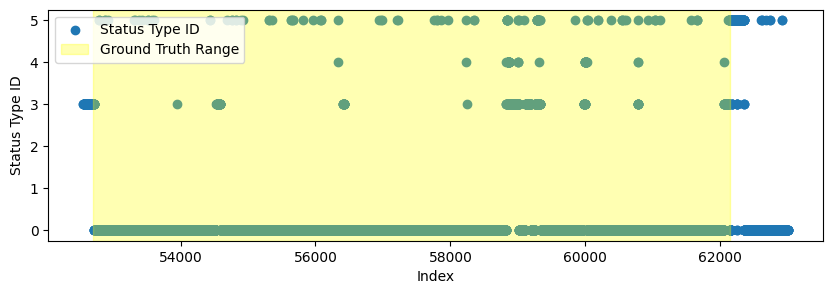

In [ ]:
# This plot is to show the inex range of anomaly of the corresponding dataset

# Scatter plot
plt.figure(figsize=(10,3))
plt.scatter(df_test.index, df_test['status_type_id'], label='Status Type ID')

# Highlight ground truth range
plt.axvspan(52704, 62138, color='yellow', alpha=0.3, label='Ground Truth Range')

plt.xlabel('Index')
plt.ylabel('Status Type ID')
plt.legend()



Hover the cursor and check for the index range and gorund truth, and predicition for better understanding

In [14]:
df_vis=full_clustering_pipeline(df_hourly_test, fault_start=52704, fault_end=62138)

✅ Silhouette Score (no noise): 0.2074


In [15]:
from typing import Tuple, List
import numpy as np

def evaluate_care_score(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    df_test: pd.DataFrame,
    start_id: int,
    end_id: int,
    care_model=None
) -> Tuple[float, float, float, float, float]:
    """
    Evaluate CARE Score and its components from predictions and ground truth.

    Parameters:
        y_true: Ground truth binary labels (0 = normal, 1 = anomaly)
        y_pred: Binary predictions (0/1)
        y_score: Model's soft anomaly scores or probabilities
        df_test: Test dataframe containing 'id' and 'timestamp'
        start_id: ID indicating start of known fault window
        end_id: ID indicating end of known fault window
        care_model: CAREScore object (optional, if already initialized)

    Returns:
        Tuple of (coverage, accuracy, reliability, earliness, final_care)
    """
    from model import CAREScore
    care = care_model or CAREScore(beta=0.5)

    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()

    coverage_fbeta = care.f_beta(tp, fp, fn)
    accuracy_score = care.accuracy(tn, fp)

    # Define event_list based on id range
    event_list = []
    mask = (df_test['id'] >= start_id) & (df_test['id'] <= end_id)
    indices = np.where(mask)[0]
    if len(indices) > 0:
        event_list.append((indices[0], indices[-1]))

    # Event detection
    tp_events = sum([y_pred[start:end+1].sum() > 0 for start, end in event_list])
    fn_events = len(event_list) - tp_events

    def find_events(y):
        events = []
        in_event = False
        for i, val in enumerate(y):
            if val == 1 and not in_event:
                start = i
                in_event = True
            elif val == 0 and in_event:
                end = i - 1
                events.append((start, end))
                in_event = False
        if in_event:
            events.append((start, len(y) - 1))
        return events

    pred_events = find_events(y_pred)
    fp_events = sum(
        not any(p_start <= e_end and p_end >= e_start for e_start, e_end in event_list)
        for p_start, p_end in pred_events
    )

    reliability_fbeta = care.event_f_beta(tp_events, fp_events, fn_events)

    # Earliness calculation
    earliness_scores = []
    for start, end in event_list:
        if y_pred[start:end+1].sum() > 0:
            weights = np.linspace(1, 0, end - start + 1)
            e_score = sum([p * w for p, w in zip(y_pred[start:end+1], weights)]) / sum(weights)
            earliness_scores.append(e_score)

    earliness = np.mean(earliness_scores) if earliness_scores else 0.0
    final_care = care.compute_care(coverage_fbeta, accuracy_score, reliability_fbeta, earliness)

    # Print summary
    print(f"📍 Coverage Fβ: {coverage_fbeta:.4f}")
    print(f"✅ Accuracy (Normal): {accuracy_score:.4f}")
    print(f"📦 Reliability Fβ: {reliability_fbeta:.4f}")
    print(f"⏱️ Earliness Score: {earliness:.4f}")
    print(f"🎯 Final CARE Score: {final_care:.4f}")

    return coverage_fbeta, accuracy_score, reliability_fbeta, earliness, final_care


In [16]:
 
# Extract labels and scores
y_true_new = df_vis["ground_truth"].to_numpy()
y_pred_new = df_vis["predictions"].to_numpy()
y_score_new = df_vis["AnomalyScore"].to_numpy()
df_test_new = df_anomaly[df_anomaly["train_test"] == "prediction"].reset_index(drop=True)

# Run CARE score
evaluate_care_score(
    y_true=y_true_new,
    y_pred=y_pred_new,
    y_score=y_score_new,
    df_test=df_test_new,
    start_id=52704,
    end_id=62138
)


📍 Coverage Fβ: 0.9709
✅ Accuracy (Normal): 0.6467
📦 Reliability Fβ: 1.0000
⏱️ Earliness Score: 0.2906
🎯 Final CARE Score: 0.6397


(0.9708677940994939,
 0.6467065868263473,
 1.0,
 0.2905627347283934,
 0.6397399700765256)

## Testing on other datasets of prediction frame

In [ ]:
# df_55 = pd.read_csv('55.csv', delimiter=';')
# df_81 = pd.read_csv('81.csv', delimiter=';')
# df_47 = pd.read_csv('47.csv', delimiter=';')
# df_12 = pd.read_csv('12.csv', delimiter=';')
# df_4  = pd.read_csv('4.csv',  delimiter=';')
# df_18 = pd.read_csv('18.csv', delimiter=';')
# df_28 = pd.read_csv('28.csv', delimiter=';')
# df_39 = pd.read_csv('39.csv', delimiter=';')
# df_66 = pd.read_csv('66.csv', delimiter=';')
# df_15 = pd.read_csv('15.csv', delimiter=';')
# df_78 = pd.read_csv('78.csv', delimiter=';')
df_79 = pd.read_csv('79.csv', delimiter=';')
# df_30 = pd.read_csv('30.csv', delimiter=';')
# df_33 = pd.read_csv('33.csv', delimiter=';')
# df_11 = pd.read_csv('11.csv', delimiter=';')
df_44 = pd.read_csv('44.csv', delimiter=';')
# df_49 = pd.read_csv('49.csv', delimiter=';')
# df_31 = pd.read_csv('31.csv', delimiter=';')
# df_67 = pd.read_csv('67.csv', delimiter=';')
# df_9  = pd.read_csv('9.csv',  delimiter=';')
# df_91 = pd.read_csv('91.csv', delimiter=';')
# df_5  = pd.read_csv('5.csv',  delimiter=';')
df_90 = pd.read_csv('90.csv', delimiter=';')
# df_70 = pd.read_csv('70.csv', delimiter=';')
# df_35 = pd.read_csv('35.csv', delimiter=';')
# df_16 = pd.read_csv('16.csv', delimiter=';')
# df_76 = pd.read_csv('76.csv', delimiter=';')


In [ ]:
df_hourly_test_44 =df_44.copy()
df_hourly_test_44 = preprocess_pipeline(df_hourly_test_44)
df_hourly_test_44 = df_hourly_test_44[df_hourly_test_44['train_test'] == 'prediction']
df_hourly_test_44 = downsample_to_hourly_with_index(df_hourly_test_44, time_col='time_stamp')
df_hourly_test_44 = df_hourly_test_44.drop(columns=["time_stamp", "asset_id", "id", "status_type_id"], errors="ignore")

In [ ]:
df_hourly_test_79 =df_79.copy()
df_hourly_test_79 = preprocess_pipeline(df_hourly_test_79)
df_hourly_test_79 = df_hourly_test_79[df_hourly_test_79['train_test'] == 'prediction']
df_hourly_test_79 = downsample_to_hourly_with_index(df_hourly_test_79, time_col='time_stamp')
df_hourly_test_79 = df_hourly_test_79.drop(columns=["time_stamp", "asset_id", "id", "status_type_id"], errors="ignore")

In [ ]:
df_hourly_test_90 =df_90.copy()
df_hourly_test_90 = preprocess_pipeline(df_hourly_test_90)
df_hourly_test_90 = df_hourly_test_90[df_hourly_test_90['train_test'] == 'prediction']
df_hourly_test_90 = downsample_to_hourly_with_index(df_hourly_test_90, time_col='time_stamp')
df_hourly_test_90 = df_hourly_test_90.drop(columns=["time_stamp", "asset_id", "id", "status_type_id"], errors="ignore")

# For DATASET 44.csv

In [ ]:
df_vis=full_clustering_pipeline(df_hourly_test_44, fault_start=52704, fault_end=62138)

✅ Silhouette Score (no noise): 0.2074


In [ ]:
# Extract labels and scores
y_true_new = df_vis["ground_truth"].to_numpy()
y_pred_new = df_vis["predictions"].to_numpy()
y_score_new = df_vis["AnomalyScore"].to_numpy()
df_test_new = df_anomaly[df_anomaly["train_test"] == "prediction"].reset_index(drop=True)


print( "CARE SCORE for Dataset: 44.csv")
# Run CARE score
evaluate_care_score(
    y_true=y_true_new,
    y_pred=y_pred_new,
    y_score=y_score_new,
    df_test=df_test_new,
    start_id=52704,
    end_id=62138
)


CARE SCORE for Dataset: 44.csv
📍 Coverage Fβ: 0.9709
✅ Accuracy (Normal): 0.6467
📦 Reliability Fβ: 1.0000
⏱️ Earliness Score: 0.2906
🎯 Final CARE Score: 0.6397


(0.9708677940994939,
 0.6467065868263473,
 1.0,
 0.2905627347283934,
 0.6397399700765256)

# For DATASET 90.csv

In [ ]:
df_vis=full_clustering_pipeline(df_hourly_test_90, fault_start=52848, fault_end=54591)

✅ Silhouette Score (no noise): 0.2844


In [ ]:
# Extract labels and scores
y_true_new = df_vis["ground_truth"].to_numpy()
y_pred_new = df_vis["predictions"].to_numpy()
y_score_new = df_vis["AnomalyScore"].to_numpy()
df_test_new = df_anomaly[df_anomaly["train_test"] == "prediction"].reset_index(drop=True)


print( "CARE SCORE for Dataset: 90.csv")
# Run CARE score
evaluate_care_score(
    y_true=y_true_new,
    y_pred=y_pred_new,
    y_score=y_score_new,
    df_test=df_test_new,
    start_id=52848,
    end_id=54591
)


CARE SCORE for Dataset: 90.csv
📍 Coverage Fβ: 0.8765
✅ Accuracy (Normal): 0.5053
📦 Reliability Fβ: 1.0000
⏱️ Earliness Score: 0.1093
🎯 Final CARE Score: 0.5201


(0.8764815970056145,
 0.5052631578947369,
 1.0,
 0.10925813345123613,
 0.5200522043605648)

# For DATASET 79.csv

In [ ]:
df_vis=full_clustering_pipeline(df_hourly_test_79, fault_start=52704, fault_end=52992)
# Extract labels and scores
y_true_new = df_vis["ground_truth"].to_numpy()
y_pred_new = df_vis["predictions"].to_numpy()
y_score_new = df_vis["AnomalyScore"].to_numpy()
df_test_new = df_anomaly[df_anomaly["train_test"] == "prediction"].reset_index(drop=True)


print( "CARE SCORE for Dataset: 44.csv")
# Run CARE score
evaluate_care_score(
    y_true=y_true_new,
    y_pred=y_pred_new,
    y_score=y_score_new,
    df_test=df_test_new,
    start_id=52704,
    end_id=52992
)
